In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

EVENTS = {
    "A": pd.to_datetime("2015-06-10"),  # FPH
    "B": pd.to_datetime("2016-11-23"),  # Pizzagate
    "C": pd.to_datetime("2018-09-12"),  # GreatAwakening
    "D": pd.to_datetime("2020-06-29"),  # The_Donald
    
}

EVENT_LABELS = {
    "A": "FPH Ban",
    "B": "Pizzagate Ban",
    "C": "GA Ban",
    "D": "TD Ban",
   
}

def preprocess_dataset(fname):
    data = pd.read_parquet(fname)
    data = data[['user_id', 'publish_date', 'toxicity_toxigen', ]]
    data['dt_time'] = pd.to_datetime(pd.to_datetime(data['publish_date'], unit='s').dt.date)

    user_first_time = data.groupby('user_id').agg(
        min_time = ('dt_time', lambda x: min(x))
        ).to_dict()['min_time']

    def get_user_cohort(x):

        ft = pd.to_datetime(user_first_time[x])
        if ft<EVENTS['A']:
            return 'beforeA'
        elif ft<EVENTS['B']:
            return 'betweenA-B'
        elif ft<EVENTS['C']:
            return 'betweenB-C'
        elif ft<EVENTS['D']:
            return 'betweenC-D'
        else:
            return 'afterD'
        
    data['cohort'] = data['user_id'].apply(get_user_cohort)

    return data

from plot_functions import plot_toxicity_per_cohort
from datetime import timedelta
import pandas as pd


def toxicity_dict(group='total'):

    return {f'{group}_Nusers':[],
            f'{group}_Nposts':[],
           f'{group}_toxicity_user_mean':[],
           f'{group}_toxicity_activity_mean':[],
           f'{group}_toxicity_sum':[],
           }

def update_dict(results, df_slice_cohort, cohort='all'):
    results[f'{cohort}_toxicity_user_mean'].append(df_slice_cohort.groupby('user_id').toxicity_toxigen.apply('mean').mean())
    results[f'{cohort}_toxicity_activity_mean'].append(df_slice_cohort['toxicity_toxigen'].mean())
    results[f'{cohort}_Nusers'].append(len(df_slice_cohort['user_id'].unique()))
    results[f'{cohort}_Nposts'].append(len(df_slice_cohort))
    results[f'{cohort}_toxicity_sum'].append(df_slice_cohort['toxicity_toxigen'].sum())
    return results


def calculate_toxicity_over_time(data, window_days=30, step_days = 1):


    t_min = min(data['dt_time'])
    t_max = max(data['dt_time'])

    nsteps = (t_max-t_min).days

    #init dicts to save results

    results = {'step': [],
            'window_tmin': [],
            'window_tmax': [],
            }

    #add global measure
    results.update(toxicity_dict(group='all'))

    #add measures per cohort
    cohorts = list(data['cohort'].unique())
    for cohort in cohorts:
        results.update(toxicity_dict(group=cohort))

    for step in range(nsteps - window_days + 2):

        window_id = step
        window_tmin = t_min + timedelta(days=step)
        window_tmax = window_tmin + timedelta(days=30)

        results['step'].append(step)
        results['window_tmin'].append(window_tmin)
        results['window_tmax'].append(window_tmax)

        #print(window_id, window_tmin, window_tmax)

        df_slice = data[(data['dt_time']>=window_tmin)&(data['dt_time']<window_tmax)].copy()
        results = update_dict(results, df_slice, cohort='all')

        for cohort in cohorts:

            df_slice_cohort = df_slice[df_slice['cohort']==cohort]      
            results = update_dict(results, df_slice_cohort, cohort=cohort)      

    df = pd.DataFrame(results)
    #df = df.fillna(0)
    return df

def plot_Nusers(df_slice):
    user_cohort = df_slice[['user_id', 'cohort']].drop_duplicates()
    sns.countplot(user_cohort, x='cohort', order=['beforeA', 'betweenA-B', 'betweenB-C', 'betweenC-D', 'afterD'])
    plt.yscale('log')
    plt.ylim(0.1, 8000)
    plt.xlabel('cohort')
    plt.ylabel('N users')
    plt.xticks(rotation=60)

def plot_toxicity(df_slice):
    sns.barplot(df_slice, x='cohort', y='toxicity_toxigen', order=['beforeA', 'betweenA-B', 'betweenB-C', 'betweenC-D', 'afterD'] )
    plt.ylim(0, 0.3)
    plt.xlabel('cohort')
    plt.ylabel('Mean Active Toxicity')
    plt.xticks(rotation=60)

def plot_user_toxicity(df_slice):
    df_slice = df_slice.groupby(['user_id', 'cohort']).toxicity_toxigen.apply('mean').reset_index()
    sns.barplot(df_slice, x='cohort', y='toxicity_toxigen', order=['beforeA', 'betweenA-B', 'betweenB-C', 'betweenC-D', 'afterD'] )
    plt.ylim(0, 0.3)
    plt.xlabel('cohort')
    plt.ylabel('Mean User Toxicity')
    plt.xticks(rotation=60)


def plot_toxicity_per_cohort(data):

    plt.rcParams["figure.figsize"] = (18, 9)
    plt.subplots_adjust(left=0.1,bottom=0.1,right=0.9,top=0.9,wspace=0.8,hspace=0.8)

    xx = 3; yy=5; i=1

    plt.subplot(xx, yy, i)
    df_slice = data[data['dt_time']<EVENTS['A']]
    plot_Nusers(df_slice)
    plt.title('Before A')
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['A'])&(data['dt_time']<EVENTS['B'])]
    plot_Nusers(df_slice)
    plt.title('Between A-B')
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['B'])&(data['dt_time']<EVENTS['C'])]
    plot_Nusers(df_slice)
    plt.title('Between B-C')
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['C'])&(data['dt_time']<EVENTS['D'])]
    plot_Nusers(df_slice)
    plt.title('Between C-D')
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['D'])]
    plot_Nusers(df_slice)
    plt.title('After D')
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[data['dt_time']<EVENTS['A']]
    plot_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['A'])&(data['dt_time']<EVENTS['B'])]
    plot_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['B'])&(data['dt_time']<EVENTS['C'])]
    plot_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['C'])&(data['dt_time']<EVENTS['D'])]
    plot_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['D'])]
    plot_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[data['dt_time']<EVENTS['A']]
    plot_user_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['A'])&(data['dt_time']<EVENTS['B'])]
    plot_user_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['B'])&(data['dt_time']<EVENTS['C'])]
    plot_user_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['C'])&(data['dt_time']<EVENTS['D'])]
    plot_user_toxicity(df_slice)
    i+=1

    plt.subplot(xx, yy, i)
    df_slice = data[(data['dt_time']>=EVENTS['D'])]
    plot_user_toxicity(df_slice)
    i+=1

In [2]:
#Calculate Toxocity
subverses = ['funny', 'gaming', 'pics', 'videos', 'gifs', 'technology',]

for subv in subverses:
    print(subv)

    fname = '/home/anav/socio/2025-Reddit-Voat/data/voat_%s_madoc.parquet'%subv
    data = preprocess_dataset(fname)
    df = calculate_toxicity_over_time(data)
    df.to_csv('../results/toxicity_%s.csv'%subv, index=None)

funny
gaming
pics
videos
gifs
technology


funny


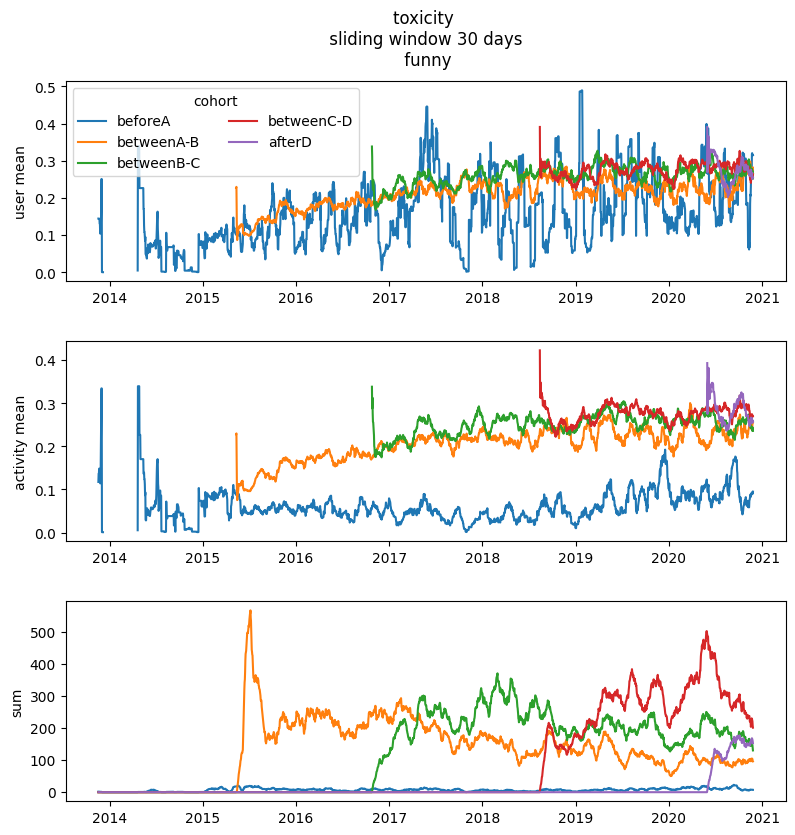

gaming


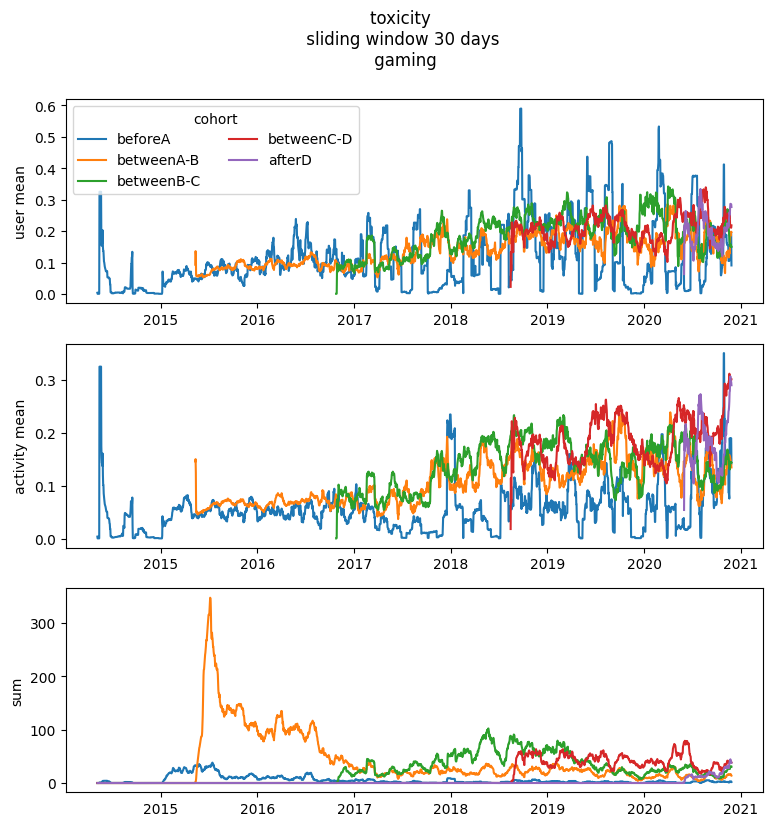

pics


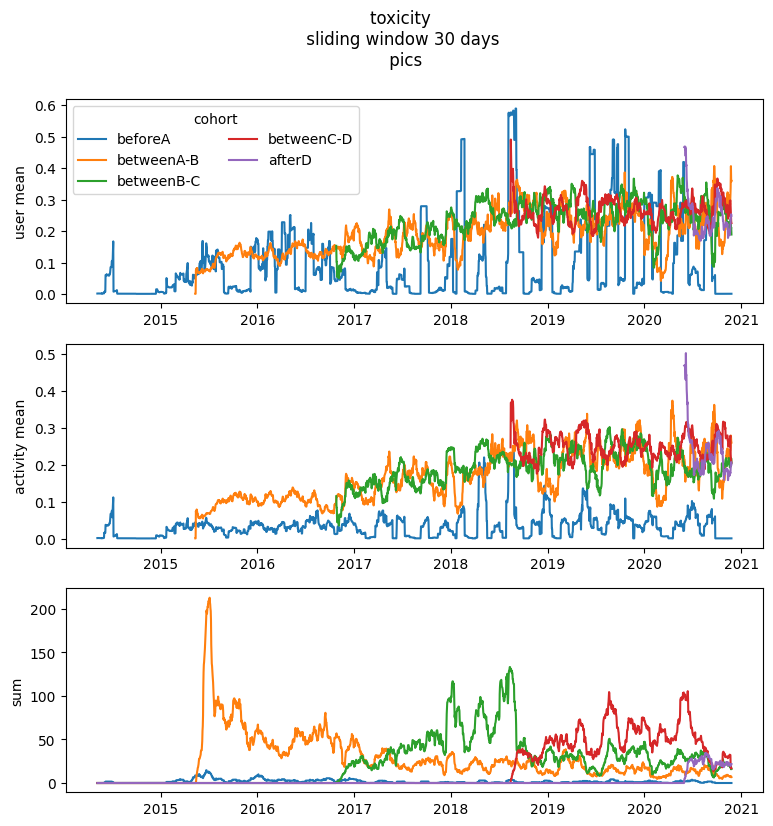

videos


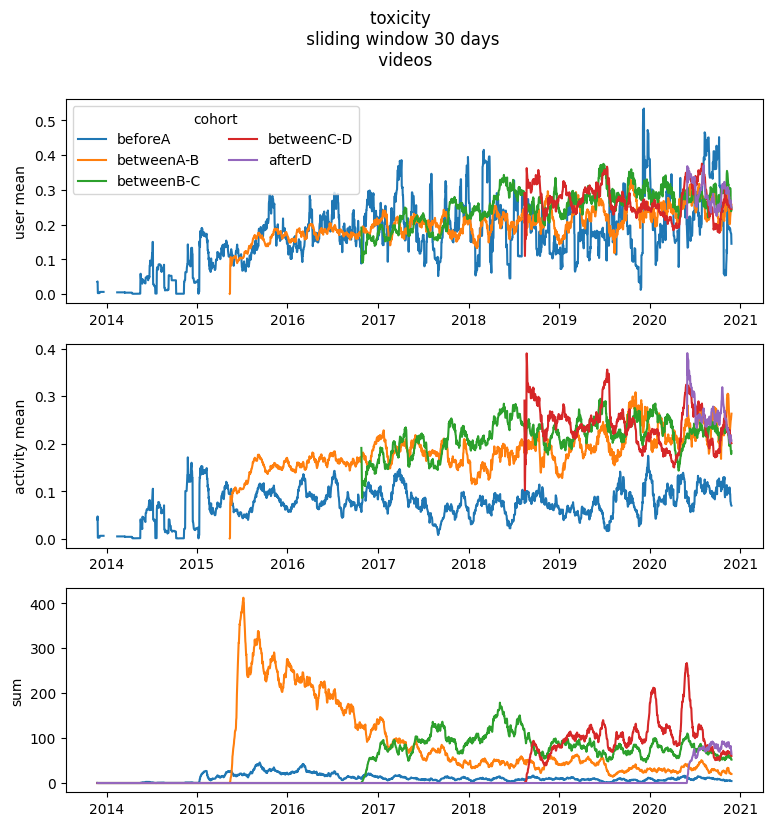

gifs


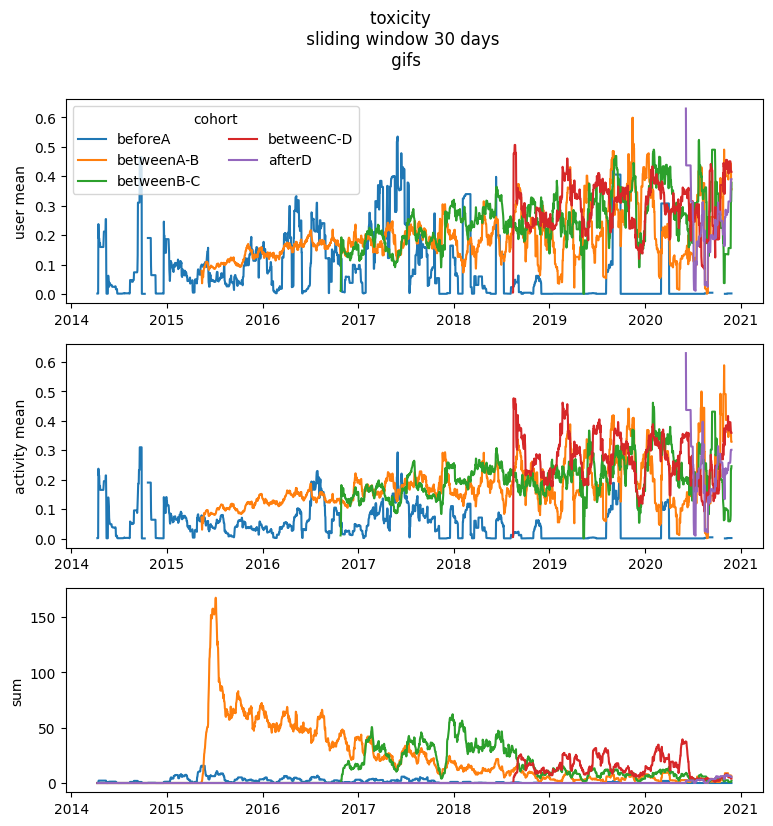

technology


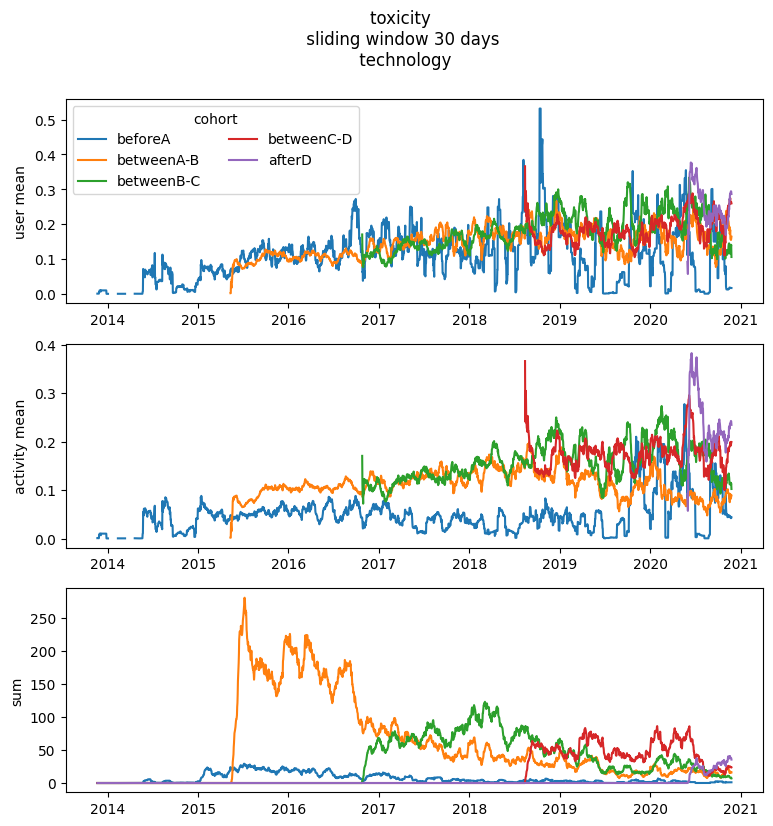

In [3]:
# Plot Toxicity Time Series

cohorts=['beforeA', 'betweenA-B', 'betweenB-C', 'betweenC-D', 'afterD']
subverses = ['funny', 'gaming', 'pics', 'videos', 'gifs', 'technology',]

plt.rcParams["figure.figsize"] = (9, 9)
plt.subplots_adjust(left=0.1,bottom=0.1,right=0.9,top=0.9,wspace=0.2,hspace=0.3)

for subv in subverses:
    print(subv)

    fname = '../results/toxicity_%s.csv'%subv
    df = pd.read_csv(fname)
    df['window_tmin'] = pd.to_datetime(df['window_tmin'])

    plt.subplot(3, 1, 1)
    for cohort in cohorts: 
        plt.plot(df['window_tmin'], df[f'{cohort}_toxicity_user_mean'], label=cohort)
    plt.ylabel('user mean')
    plt.legend(title='cohort', ncol=2)

    plt.subplot(3, 1, 2)
    for cohort in cohorts: 
        plt.plot(df['window_tmin'], df[f'{cohort}_toxicity_activity_mean'], label=cohort)
    plt.ylabel('activity mean')
    #plt.legend(title='cohort', ncol=2)

    plt.subplot(3, 1, 3)
    for cohort in cohorts: 
        plt.plot(df['window_tmin'], df[f'{cohort}_toxicity_sum'], label=cohort)
    plt.ylabel('sum')
    #plt.legend(title='cohort', ncol=2)
    
    plt.suptitle('toxicity \n sliding window 30 days \n %s'%subv)

    plt.savefig('../figures/toxicity_ts_%s.png'%subv)
    plt.show()

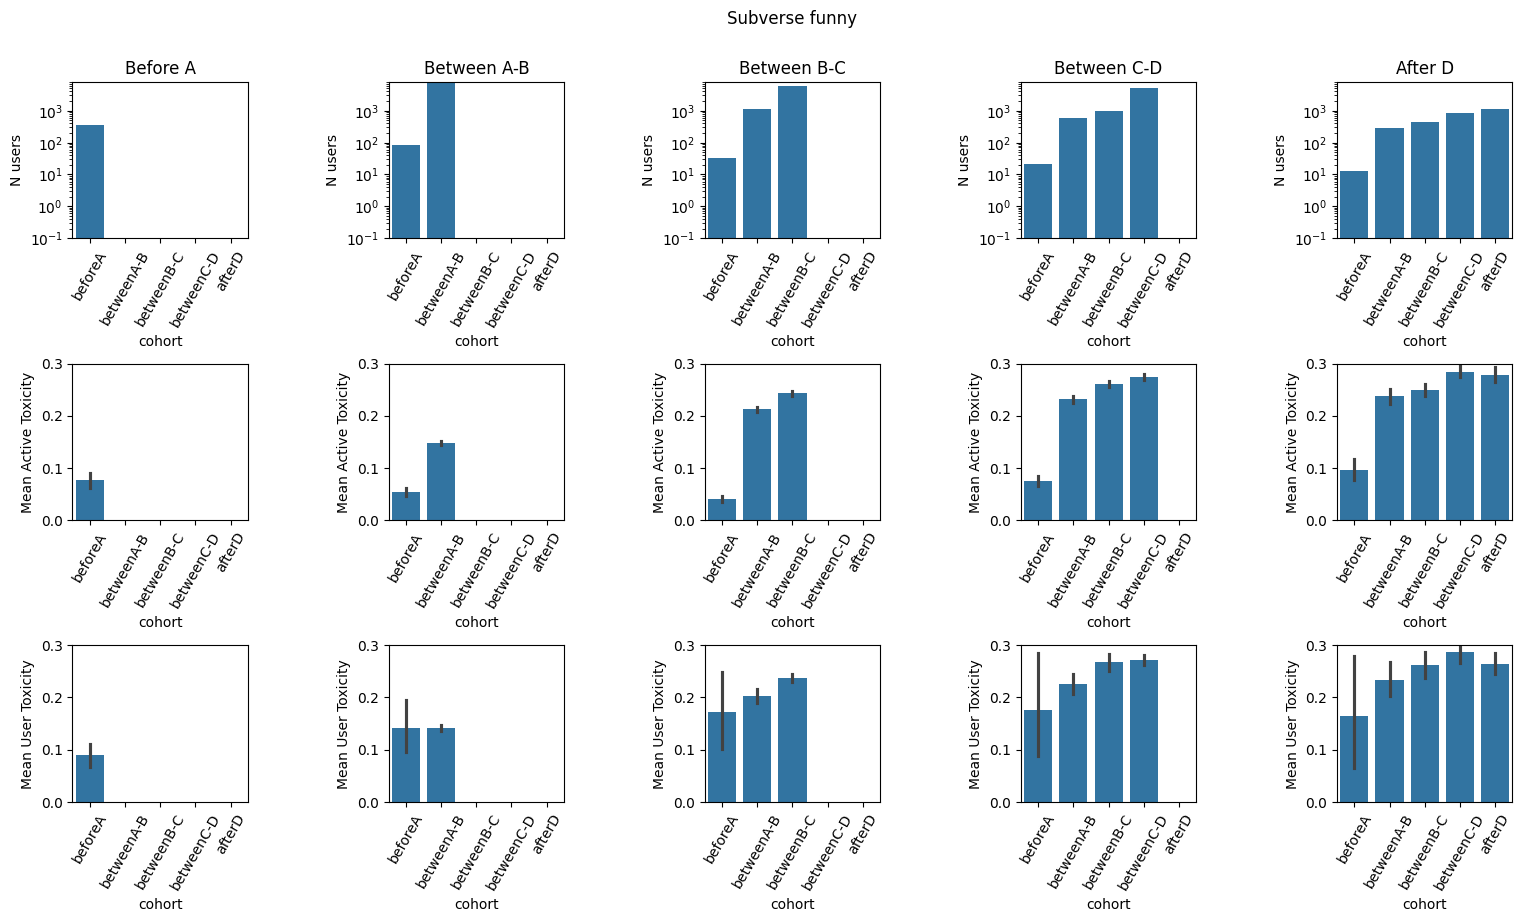

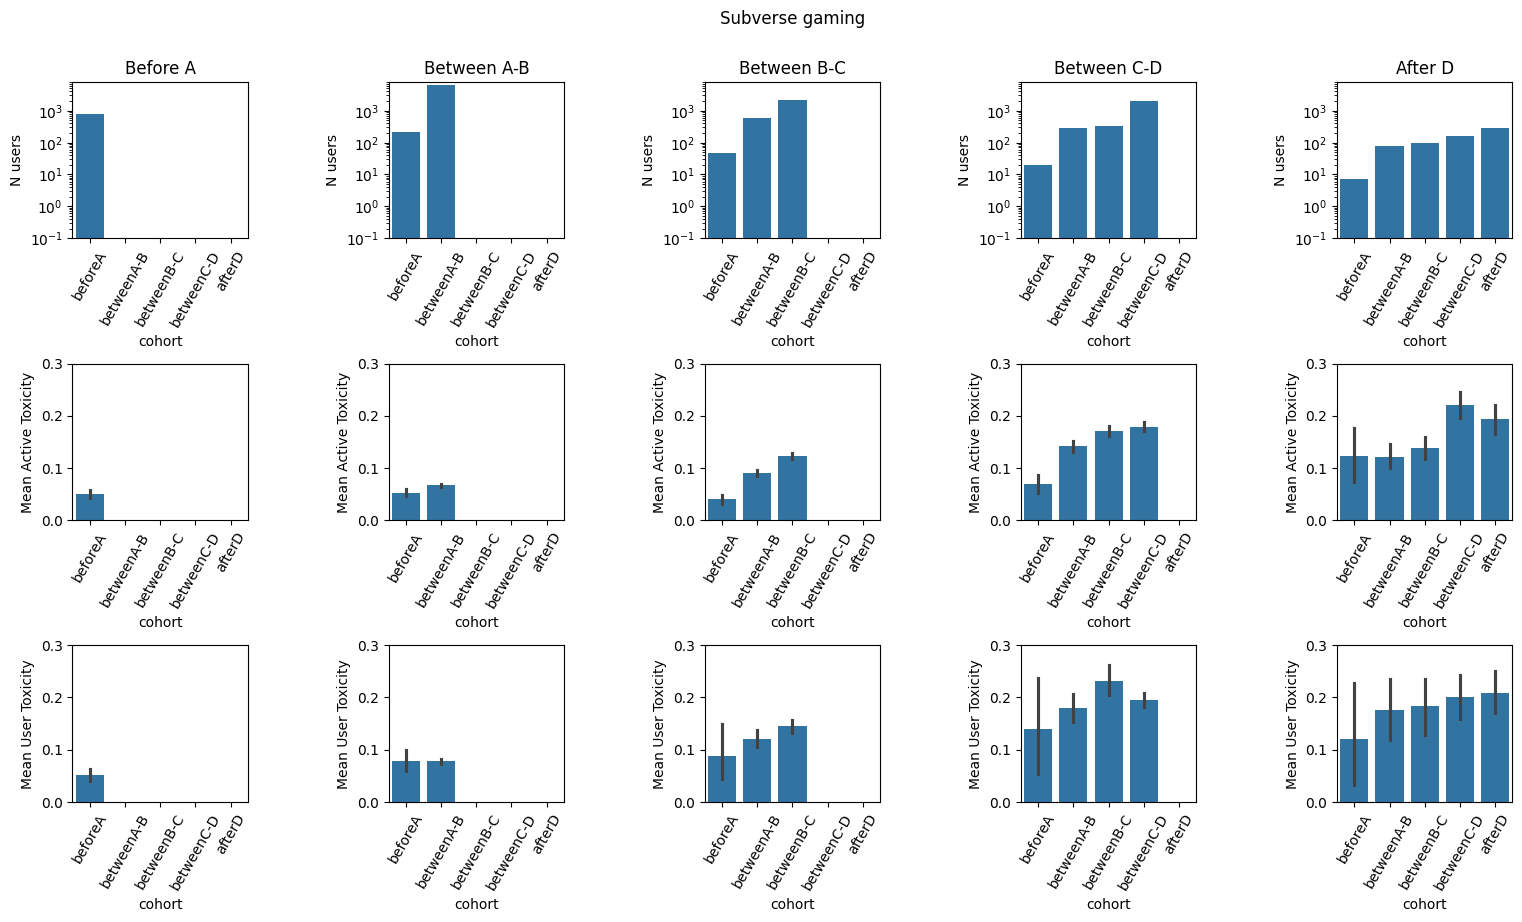

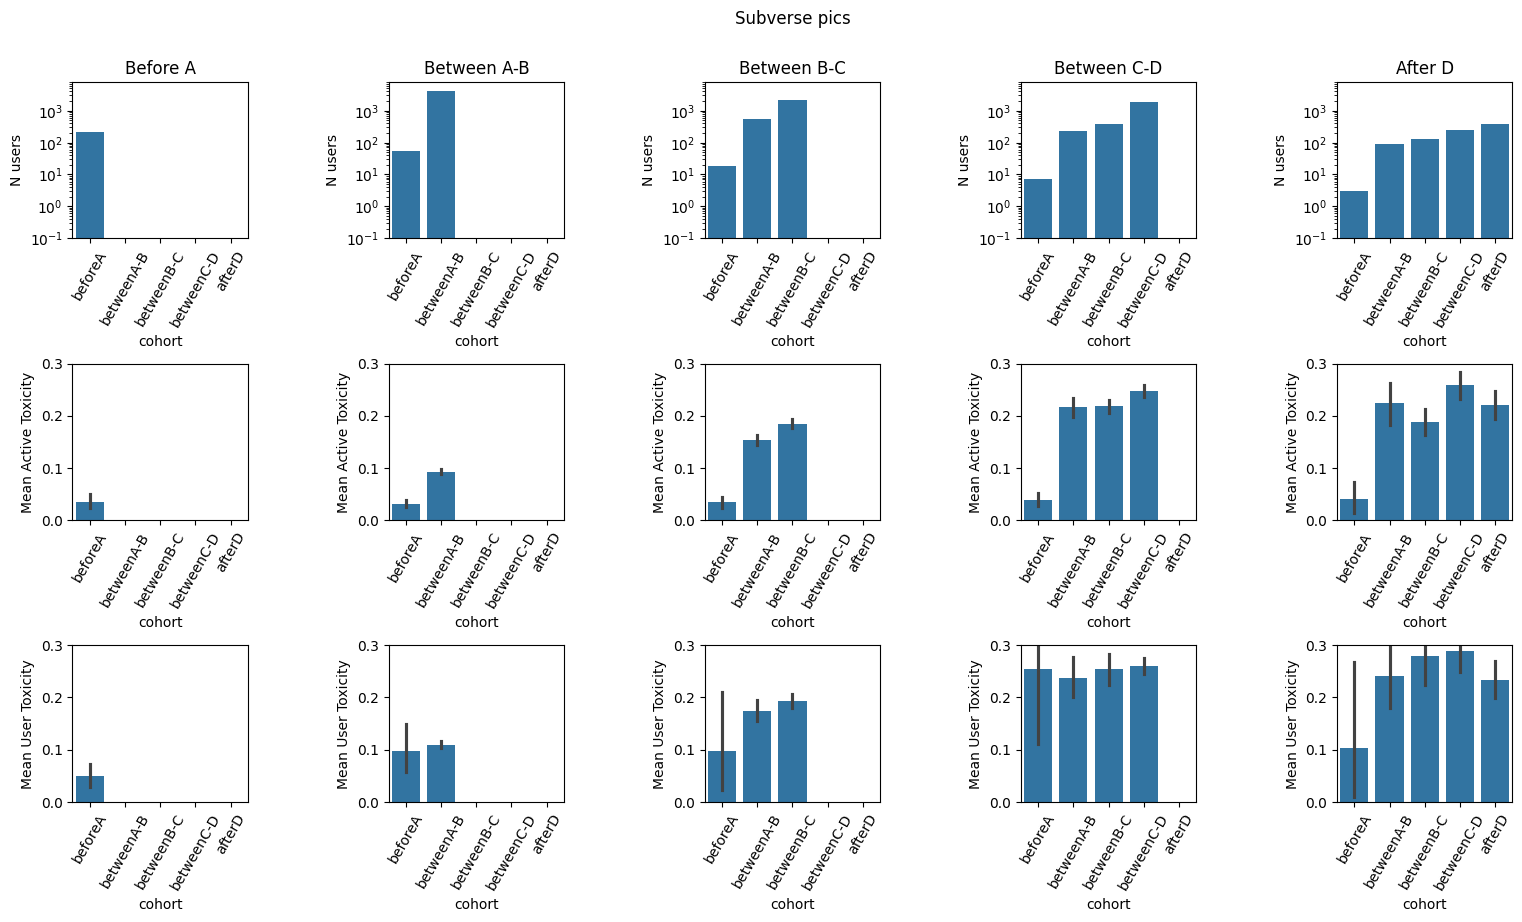

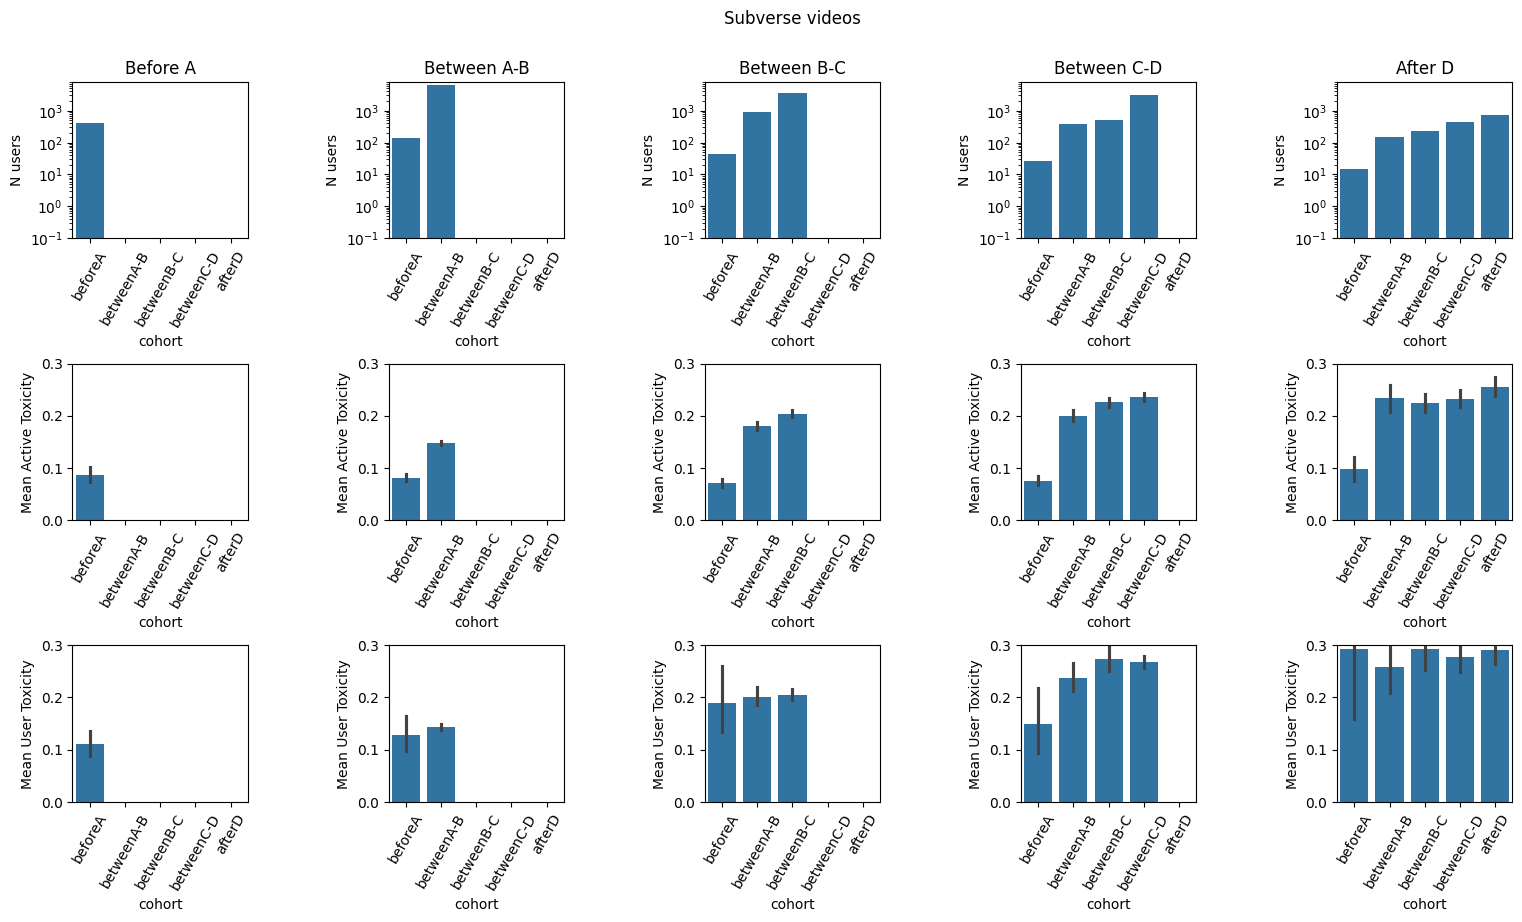

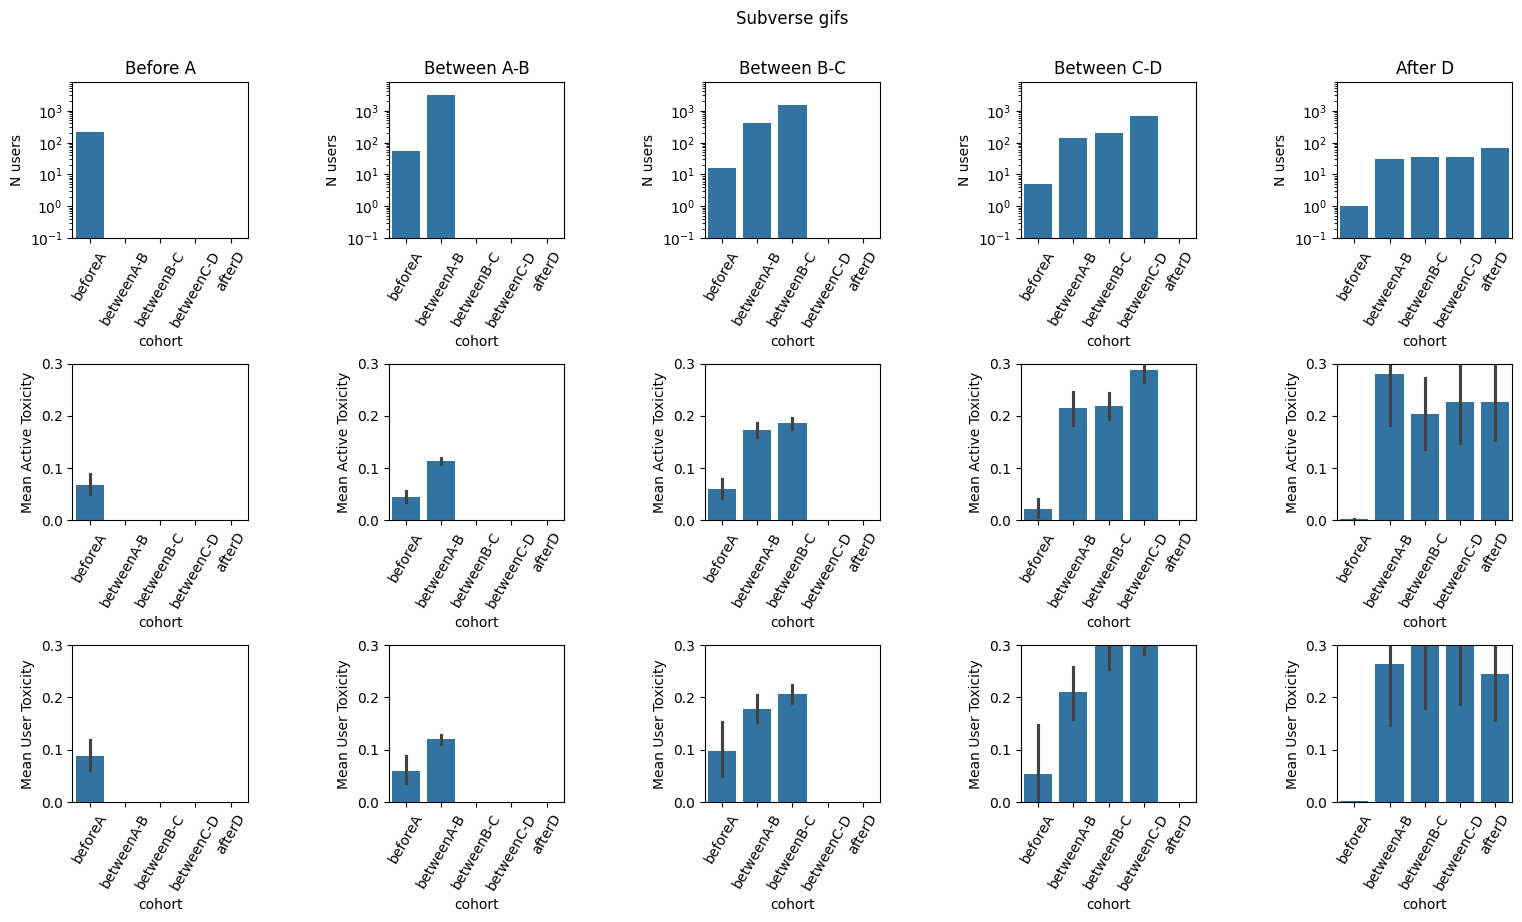

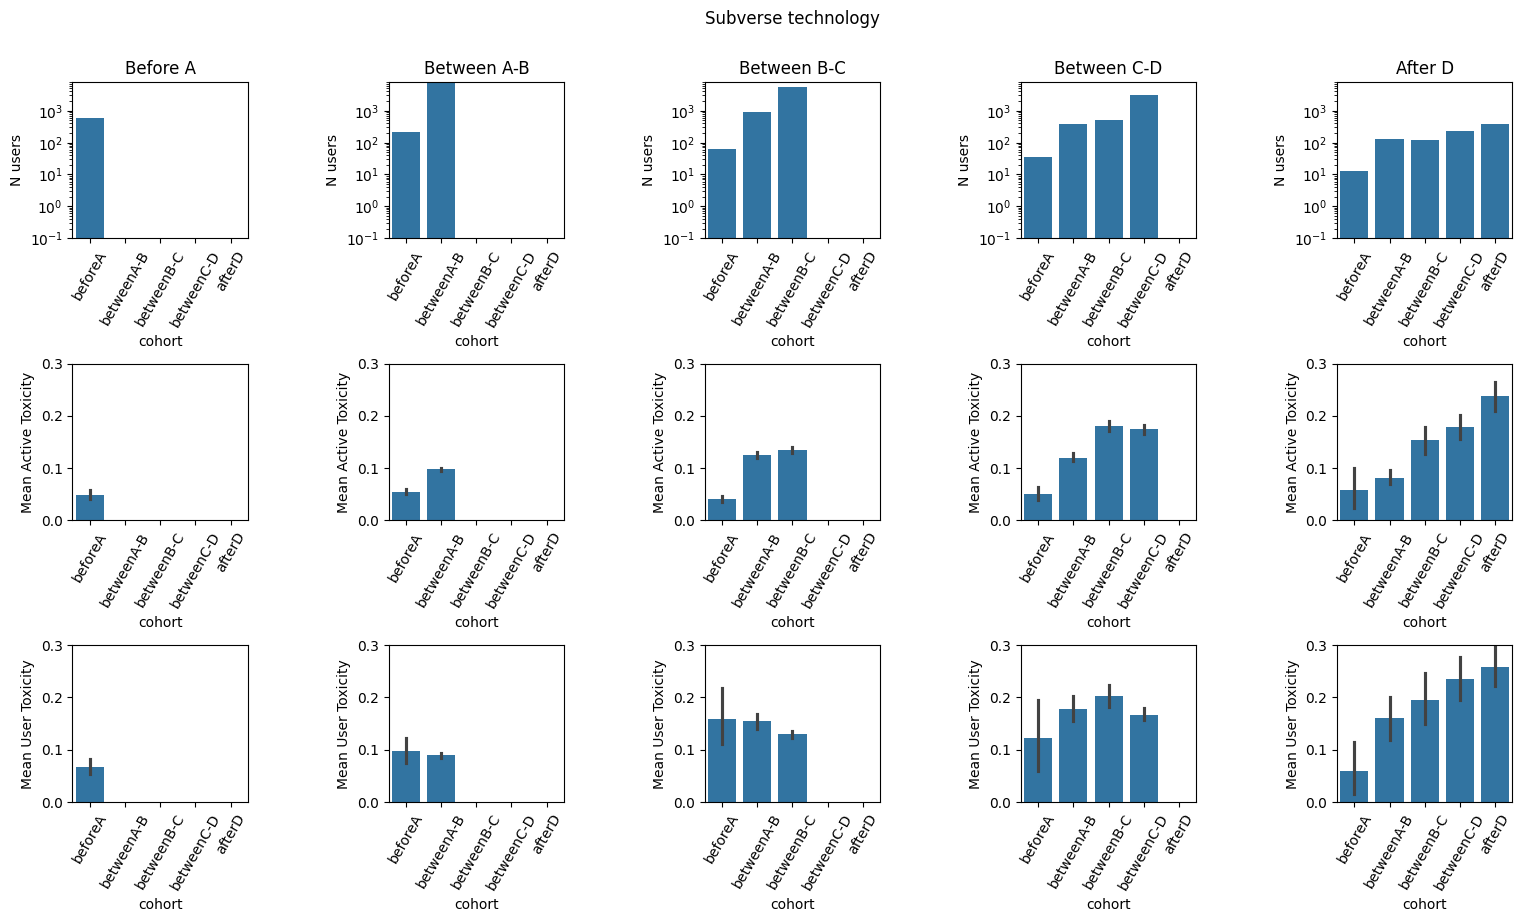

In [4]:
subverses = ['funny', 'gaming', 'pics', 'videos', 'gifs', 'technology',]

for subv in subverses:

    fname = '/home/anav/socio/2025-Reddit-Voat/data/voat_%s_madoc.parquet'%subv

    data = preprocess_dataset(fname)
    plot_toxicity_per_cohort(data)
    plt.suptitle('Subverse %s'%subv)
    
    plt.show()